## Example 3a:
Exploratory study of how the uncertainty in the predicted aberrations depends on how far the beam is from focus.

We now take a break from ML to do some physics.

A mixed-density model is fitted on single-z images, similarly to in [`zstack_decoding/example_2d.ipynb`](zstack_decoding/example_2d.ipynb).
The model is then used to simulate a batch of z-stacks and their true, underlying aberrations. Single-z images from those z-stacks are then run through inference, and the predicted uncertainty for each coefficient is plotted as a function of defocus through each z-stack. These predicted uncertainties can then be compared to their priors and the van Trees limit at each z-position.

Further down, we test out simulation-based calibration (SBC), and find significant non-uniformities. This seems to come from miscalibration in the predicted means, rather than the predicted uncertainties: the model was originally given a minimum component allocation of 0.05 to hard-avert component collapse, but that's skewing the steady-state result. The min component allocation was from before the component weight entropy loss was added, so we can lift it now, and see nicely uniform SBC results with the retrained model. I'll keep the flawed model around to show the journey, since it's pretty satisfying.

In [1]:
import itertools
import logging
import math
from pathlib import Path
import warnings

import numpy as np
import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
    get_default_mixture_config,
)
from cynosure.information.calibration import (
    calculate_rank_statistics,
    generate_and_predict,
    get_expected_rank_statistics,
    test_rank_uniformity,
)
from cynosure.information.fisher_information import calculate_fisher_matrix, calculate_van_trees_bounds
from cynosure.object_distribution import FixedBead
from cynosure.utilities.training_utils import NoValidationBar, safe_load_from_checkpoint
from cynosure.utilities.visualization import plot_stack
from cynosure.zstack_decoding import ZstackSolver_MixedDensity
from cynosure.zstack_decoding.posterior_heads import get_default_cnn_encoder_spec

#### Simulation setup

In [4]:
use_pretrained = True  # enable to load weights from one of my checkpoints

train_cfg = get_default_training_config()
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config(
    min_photons=10_000,
    max_photons=10_000,
    max_background=0,
)
encoder_spec = get_default_cnn_encoder_spec(
    spatial_hidden_channels=(32, 64),
    embedding_dims=128,
)

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)
mixture_cfg = get_default_mixture_config(
    mixing_warmup_epochs=10,
    min_allocation=0.05,
)

In [5]:
rng_seed = 123
z_jitter = 1.5  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Fitting a model

In [6]:
_ = pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_MixedDensity(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    mixture_cfg=mixture_cfg,
    noise_cfg=noise_cfg,
    encoder_spec=encoder_spec,
)
solver = solver.to(device)

Seed set to 123


In [7]:
checkpoint_path = Path("./pretrained_models/example_3a/checkpoints/final.ckpt")
if use_pretrained and checkpoint_path.is_file():
    solver = safe_load_from_checkpoint(checkpoint_path, solver).eval()
else:
    trainer = pl.Trainer(
        max_epochs=600,  # much longer than usual, to tighten the bounds
        accelerator=device,
        log_every_n_steps=100,
        callbacks=[NoValidationBar()],
        gradient_clip_val=1.0,
    )
    trainer.fit(solver)
    solver = solver.eval()

#### Analysis (i.e., the good stuff)

Generate a bunch of fresh examples and their predictions at different z-positions. Z-planes are still separate (batched), not joint z-stacks.

In [8]:
_ = pl.seed_everything(rng_seed+1, workers=True)
solver = solver.to(device)

Seed set to 124


In [9]:
batch_size = 64
z_max = 1.5
num_z = 19

z = torch.linspace(-z_max, z_max, num_z, device=solver.device)
phase_coefs, amp_coefs = solver.simulator.sample_coefficients(batch_size)

In [10]:
with torch.inference_mode():
    z_exp = z.unsqueeze(0).expand((batch_size, num_z)).reshape(batch_size*num_z)
    defocus_exp = solver.propagator.defocus_from_objective_z(z_exp)
    phase_coefs_exp = phase_coefs.unsqueeze(1).expand((batch_size, num_z, -1)).reshape(batch_size*num_z, -1)
    amp_coefs_exp = amp_coefs.unsqueeze(1).expand((batch_size, num_z, -1)).reshape(batch_size*num_z, -1)

    images = solver.simulator.simulate_stacks(defocus_exp, phase_coefs_exp, amp_coefs_exp)
    images = solver.simulator.apply_noise(images)
    images = solver.simulator.normalize_stack(images)
    mixture_family = solver.predict_distribution(images)

mixture = mixture_family.mixture_distribution
dist = mixture_family.component_distribution

covariances = dist.covariance_matrix
sigmas = covariances.diagonal(dim1=-2, dim2=-1).sqrt()
sigmas = sigmas.reshape(batch_size, num_z, solver.num_components, -1)  # [B, Z, num_components, num_coefficients]

images = images.squeeze(1).unflatten(0, (batch_size, num_z))  # [B*Z, 1, H, W] -> [B, Z, H, W]

For each coefficient, plot the predicted uncertainty as a function of the image's true defocus.

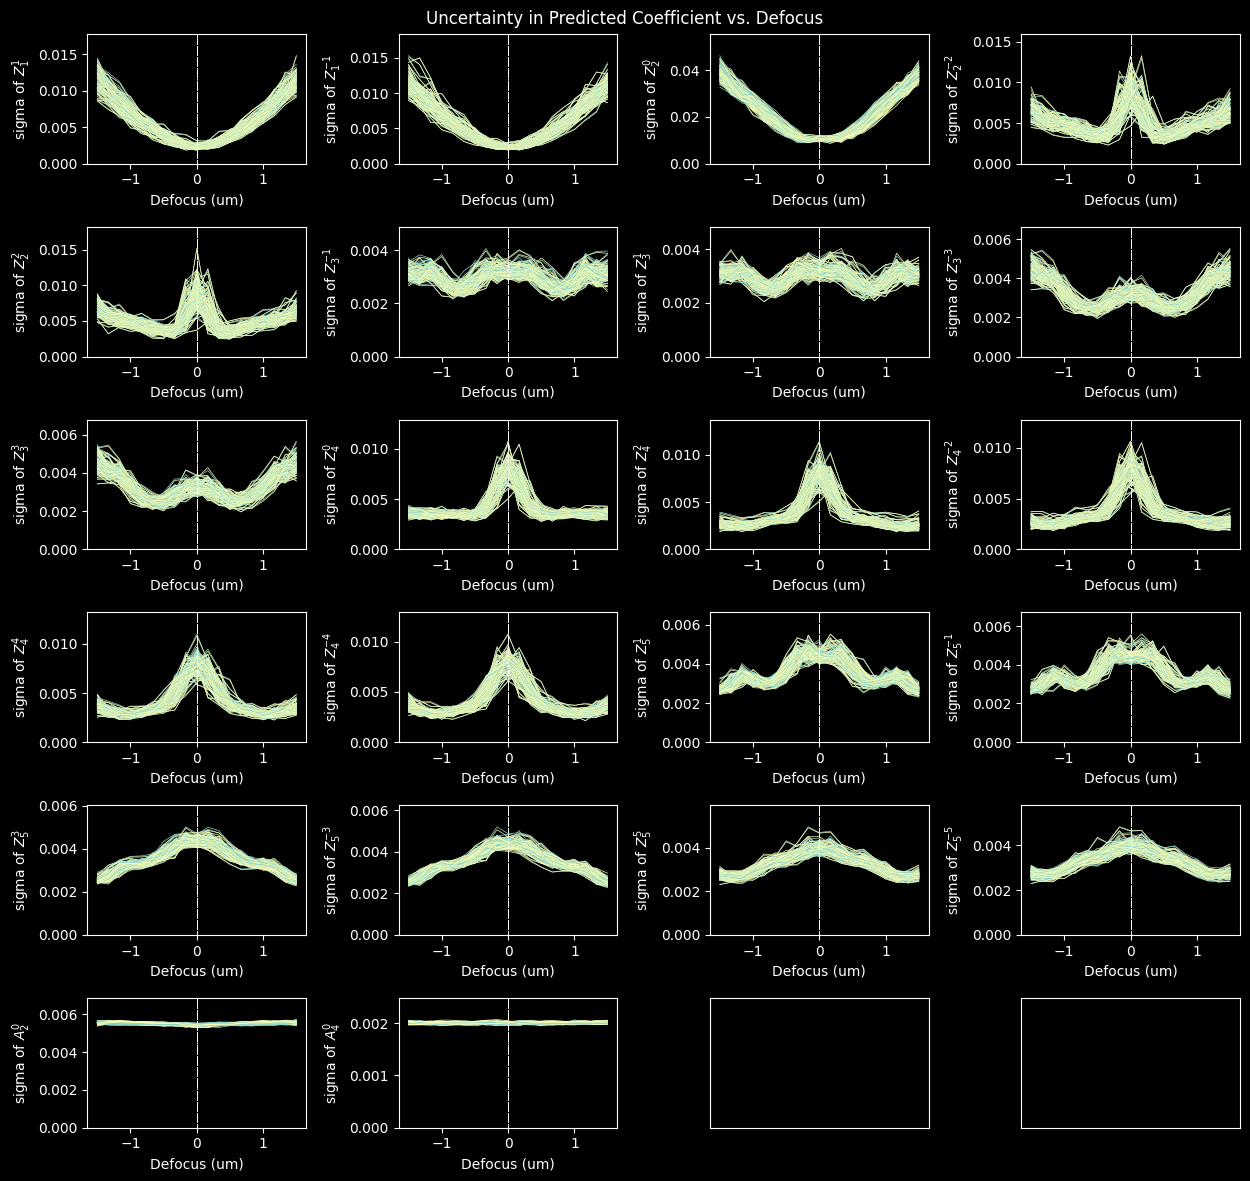

In [11]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        for bidx, cidx in itertools.product(range(batch_size), range(solver.num_components)):
            ax.plot(z.numpy(force=True), sigmas[bidx, :, cidx, i].numpy(force=True), lw=0.5, color=f"C{cidx}")
            ax.set_ylabel(f"sigma of {labels[i]}")
            ax.set_xlabel("Defocus (um)")
            ax.axvline(0, ls=":", lw=0.5)
        max_val = sigmas[:, :, :, i].amax().numpy(force=True)
        ax.set_ylim(0, max_val * 1.2)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle("Uncertainty in Predicted Coefficient vs. Defocus")
fig.tight_layout()

##### Three classes of behavior appear:
1. Predictions with minimal uncertainty near z=0. These include the translation terms $Z_{1}^{\pm1}$; the defocus $Z_{2}^{0}$; and $Z_{3}^{\pm3}$. The translation makes sense based on wave physics: phase variations in the pupil (Fourier) plane are conjugate to momentum in the image/object planes, which
Heisenberg tells us becomes maximally uncertain when the beam's position is well-defined. Defocus being easiest to predict near z=0 also seems reasonable, since that's where the confounding influence from other shape-perturbing aberrations will be minimized. I'm not sure why $Z_{3}^{\pm3}$ show this trend, though.

2. Predictions with maximal uncertainty near z=0. This includes most of the shape-perturbing aberrations. The Fourier explanation from the previous point also applies here: in the far field (large defocus limit), the intensity distribution mirrors the angular spectrum, allowing angular frequency (and therefore, momentum) to be optimally resolved.

3. Predictions with no significant z-trend. This is primarily the amplitude terms, which just don't seem to be very impactful.

Calculate the Fisher information matrix (averaged over the batch) for each true defocus. This'll take a minute, Jacobians are expensive.

In [12]:
fisher_matrix_samples = []
coefs = solver.coefficients.gather_nonpinned(solver.coefficients.join(phase_coefs, amp_coefs))  # [B, C_kept]
for coefs_i in coefs:  # TODO - figure out a way to vectorize this later
    _, fisher_matrix = calculate_fisher_matrix(coefs_i, z, solver.simulator)
    fisher_matrix_samples.append(fisher_matrix.numpy(force=True))

num_coefs = solver.coefficients.num_nonpinned_coefs
fisher_matrix_samples = np.concatenate(fisher_matrix_samples)
fisher_matrix_samples = fisher_matrix_samples.reshape(batch_size, z.shape[0], num_coefs, num_coefs)  # [B, Z, C_kept, C_kept]
fisher_matrix = fisher_matrix_samples.mean(0)  # [Z, C_kept, C_kept]

Now plot the Fisher information matrix at each z. Kind of a fun visualization of how different coefficients have different relative levels of information at different z-positions. This is shown more quantitatively in the following plots.

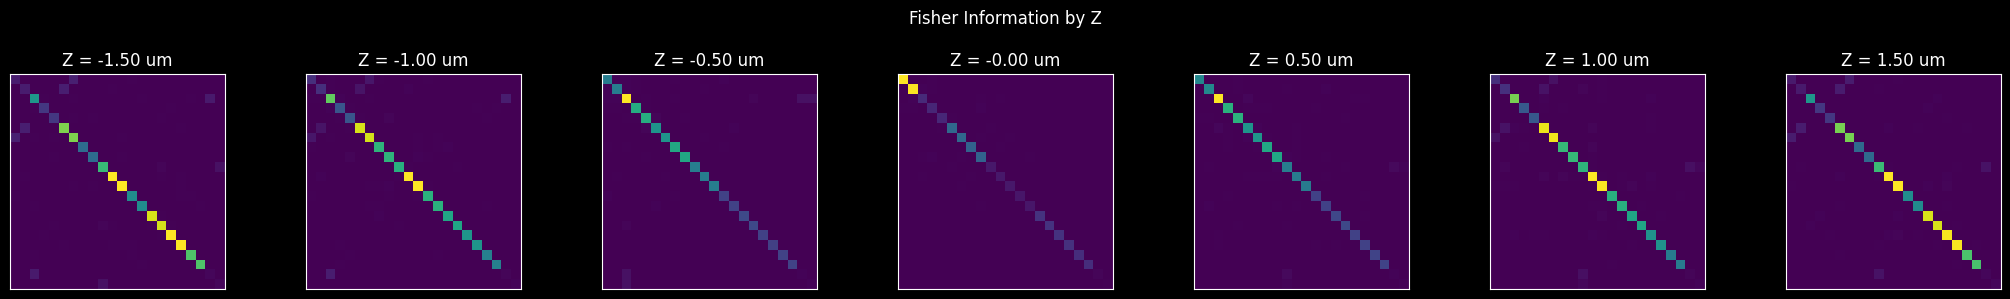

In [13]:
downsample = 3
fig = plot_stack(fisher_matrix[::downsample, :, :])  # misuse of `plot_stack`, but I won't tell anyone if you don't
for zval, ax in zip(z[::downsample], fig.axes):
    ax.set_title(f"Z = {float(zval):.2f} um")
fig.suptitle("Fisher Information by Z")
fig.tight_layout()

The van Trees bound gives the fundamental lower limit on how precisely a coefficient can be determined, based on its prior distribution and the sensitivity of the final image to it. For fun, overlay the predicted uncertainties from above so we can see how close the model got.

In [14]:
prior_sigmas = solver.coefficients.target_scales[~solver.coefficients.is_pinned].numpy(force=True)
prior_covariance = np.diag(prior_sigmas)**2
van_trees = calculate_van_trees_bounds(fisher_matrix, prior_covariance)

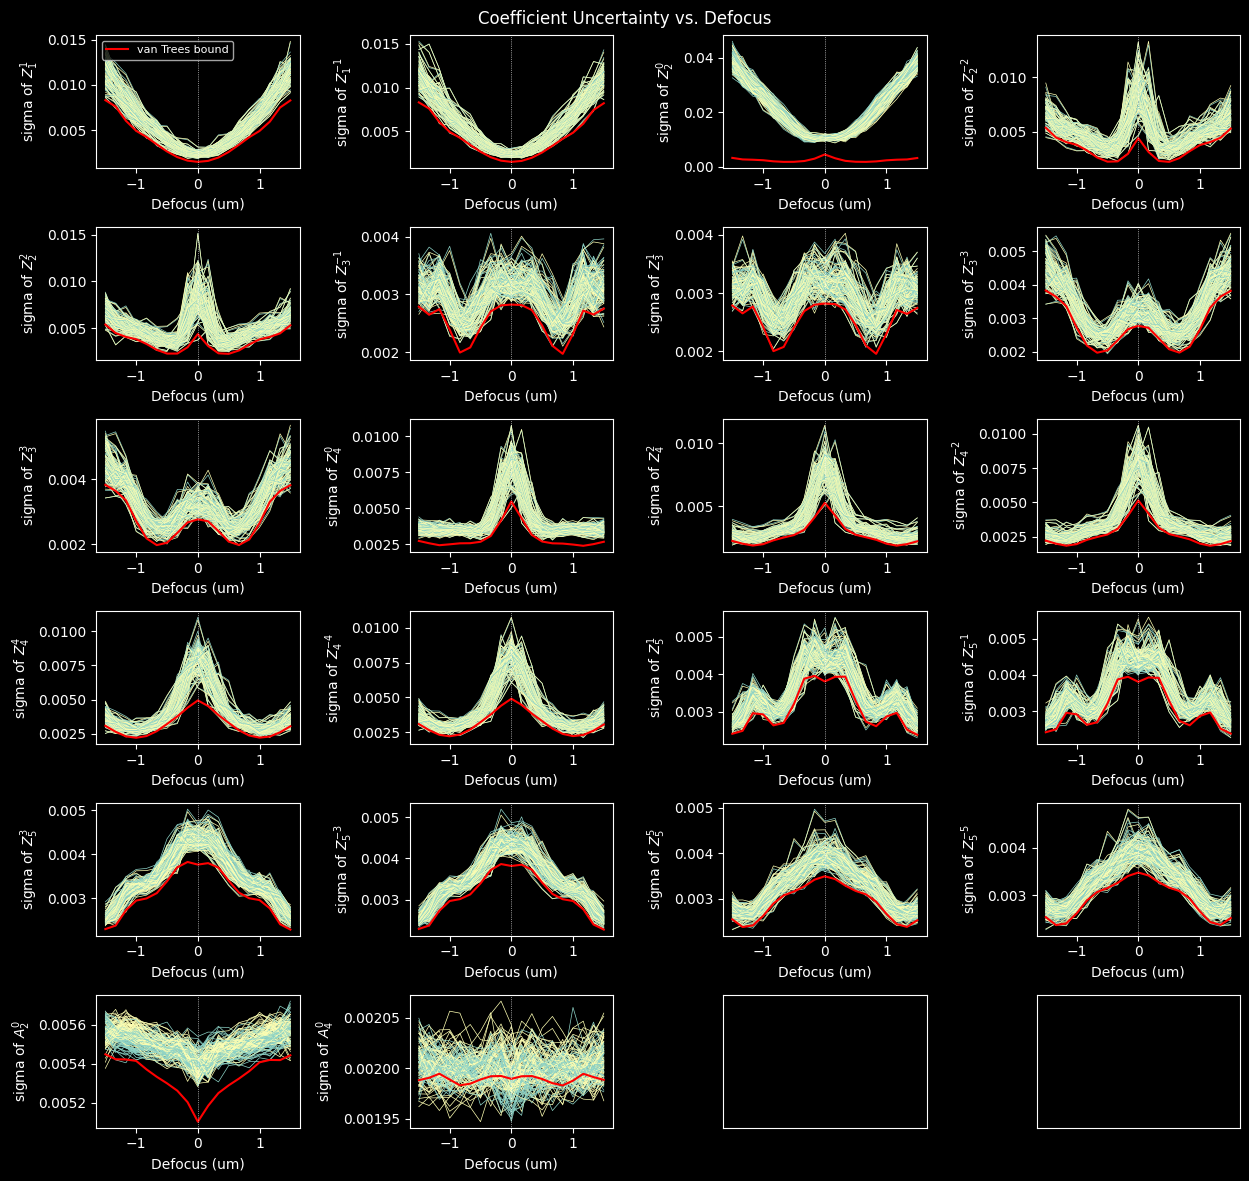

In [15]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        for bidx, cidx in itertools.product(range(batch_size), range(solver.num_components)):
            ax.plot(z.numpy(force=True), sigmas[bidx, :, cidx, i].numpy(force=True), lw=0.5, color=f"C{cidx}")
        ax.plot(z.numpy(force=True), van_trees[:, i], color="r", label="van Trees bound")
        ax.set_ylabel(f"sigma of {labels[i]}")
        ax.set_xlabel("Defocus (um)")
        ax.axvline(0, ls=":", lw=0.5)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
axarr[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Coefficient Uncertainty vs. Defocus")
fig.tight_layout()

In general, the predicted sigmas track  very nicely with the van Trees bound. The gap, usually ~10-50%, shows that the model isn't perfectly efficient. A few terms (most notably $Z_{2}^{0}$) show weirder effects that I need to think more about. Maybe something to do with how I'm folding the jittered defocus into the $Z_{2n}^{0}$ terms?

Finally, plot the van Trees bound, the predicted posterior (averaged over the batch), and the prior to see the impact of the model.

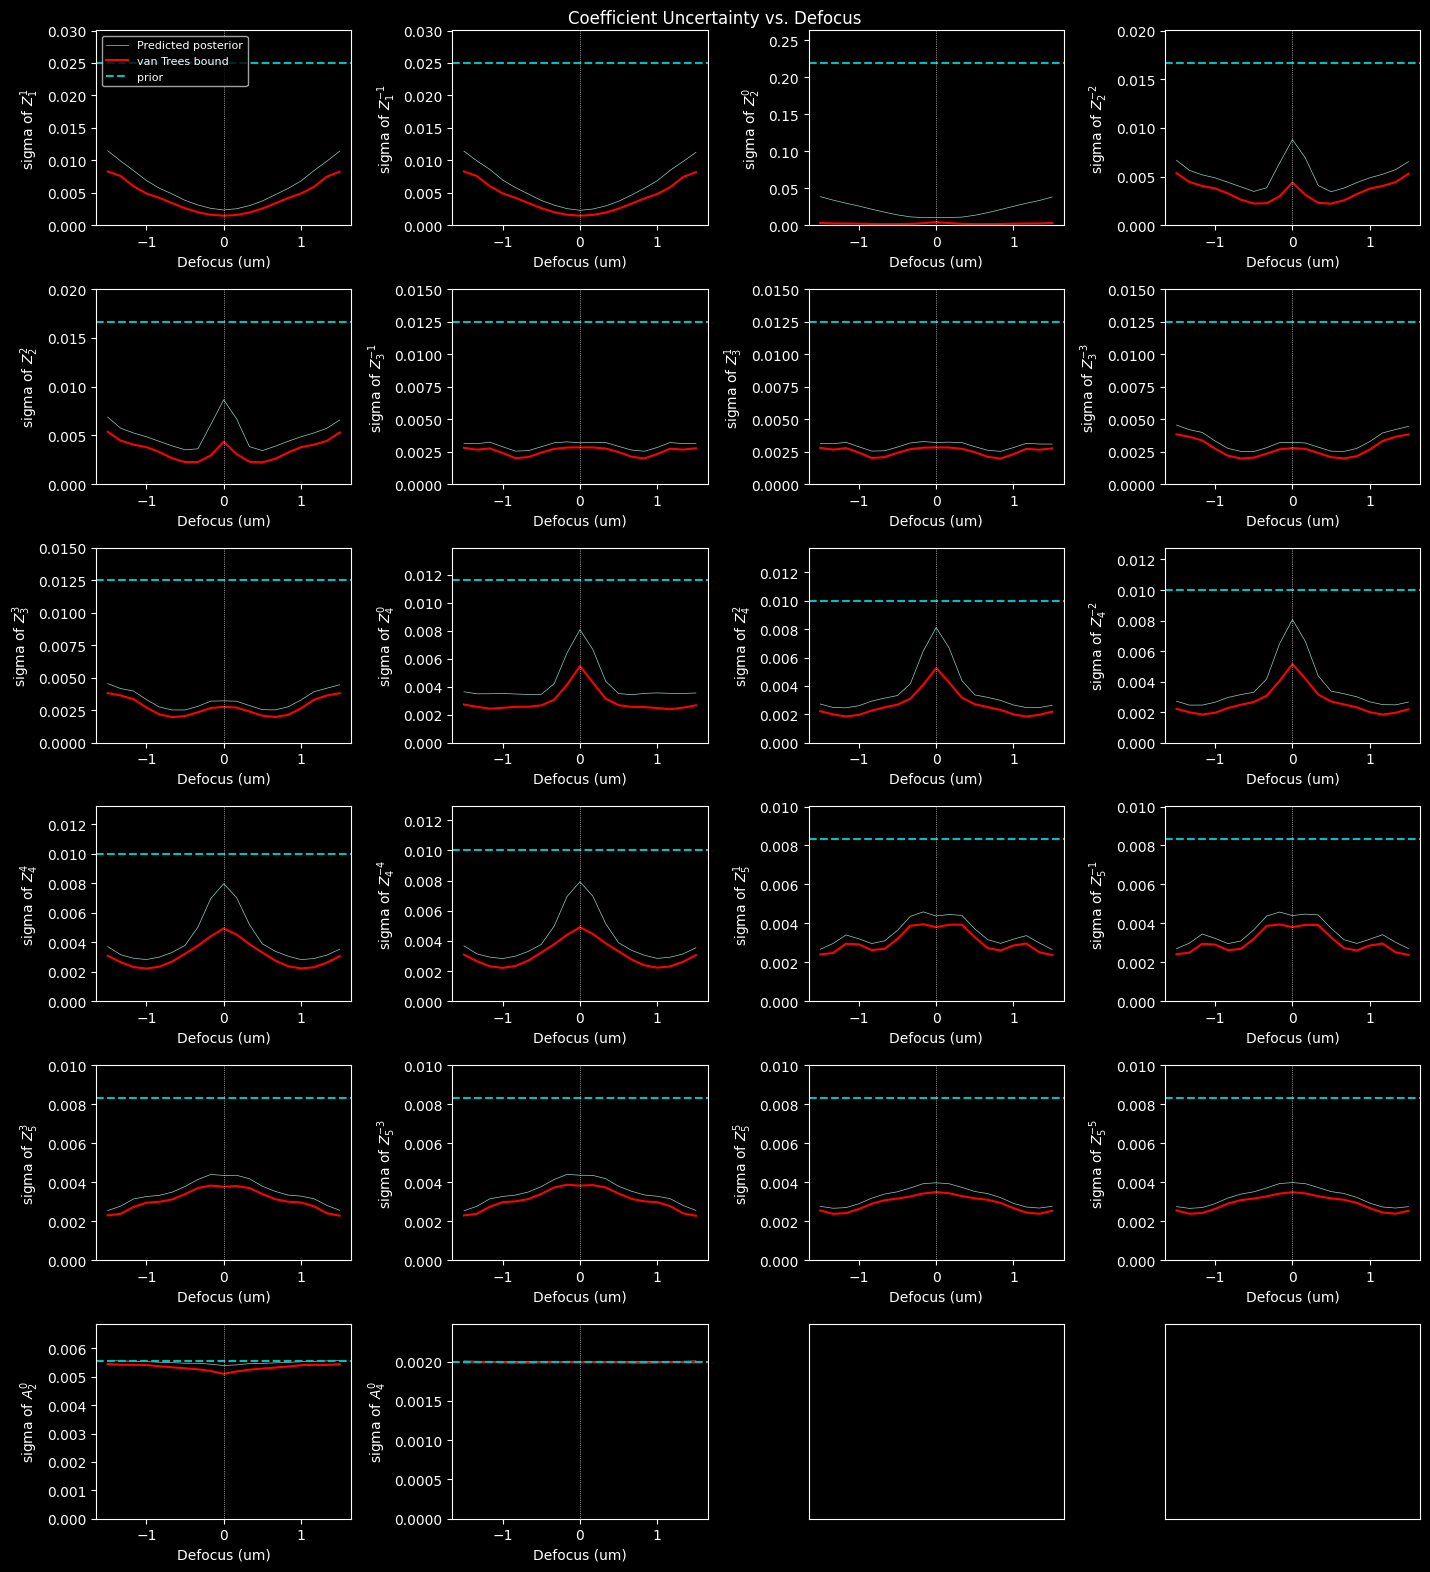

In [16]:
num_cols = 4
panel_size = 4
aspect_ratio = 0.6

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        ax.plot(z.numpy(force=True), sigmas[..., i].numpy(force=True).mean((0, 2)), lw=0.5, label="Predicted posterior")
        ax.plot(z.numpy(force=True), van_trees[:, i], color="r", label="van Trees bound")
        ax.axhline(prior_sigmas[i], ls="--", color="c", label="prior")

        max_val = max(sigmas[:, :, :, i].amax().numpy(force=True), van_trees[:, i].max(), prior_sigmas[i])
        ax.set_ylabel(f"sigma of {labels[i]}")
        ax.set_xlabel("Defocus (um)")
        ax.axvline(0, ls=":", lw=0.5)
        ax.set_ylim(0, max_val * 1.2)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
axarr[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Coefficient Uncertainty vs. Defocus")
fig.tight_layout()

Clearly, the model is pushing the uncertainty from the prior down towards the van Trees limit in almost all cases (albeit non-uniformly). The exceptions, as mentioned earlier, are the amplitude cases, where the prior is basically overlapping with the van Trees limit to begin with. The model didn't learn anything because there was nothing to learn, these amplitude terms just aren't particularly constrained by the image data. There's a lesson in here somewhere about vignetting affecting intensity, but not resolution, in microscopy.

#### Simulation-based calibration

Per SBC, calculate the rank statistics for each parameter, and check them for uniformity.

In [17]:
batch_size = 2048
num_samples = 512
num_bins = 32

In [18]:
_ = pl.seed_everything(rng_seed+2, workers=True)
coef_blocks, pred_coef_blocks = generate_and_predict(solver, batch_size, num_samples, chunk_size=8)
ranks = []
for cb, pcb in zip(coef_blocks, pred_coef_blocks):
    r = calculate_rank_statistics(cb, pcb)
    ranks.append(r)
ranks = torch.cat(ranks, dim=-1)
ranks = ranks[:, ~solver.coefficients.is_pinned.cpu()]

uniform_mean, uniform_std = get_expected_rank_statistics(batch_size, num_bins)
pvalues = test_rank_uniformity(ranks, num_bins)

Seed set to 125


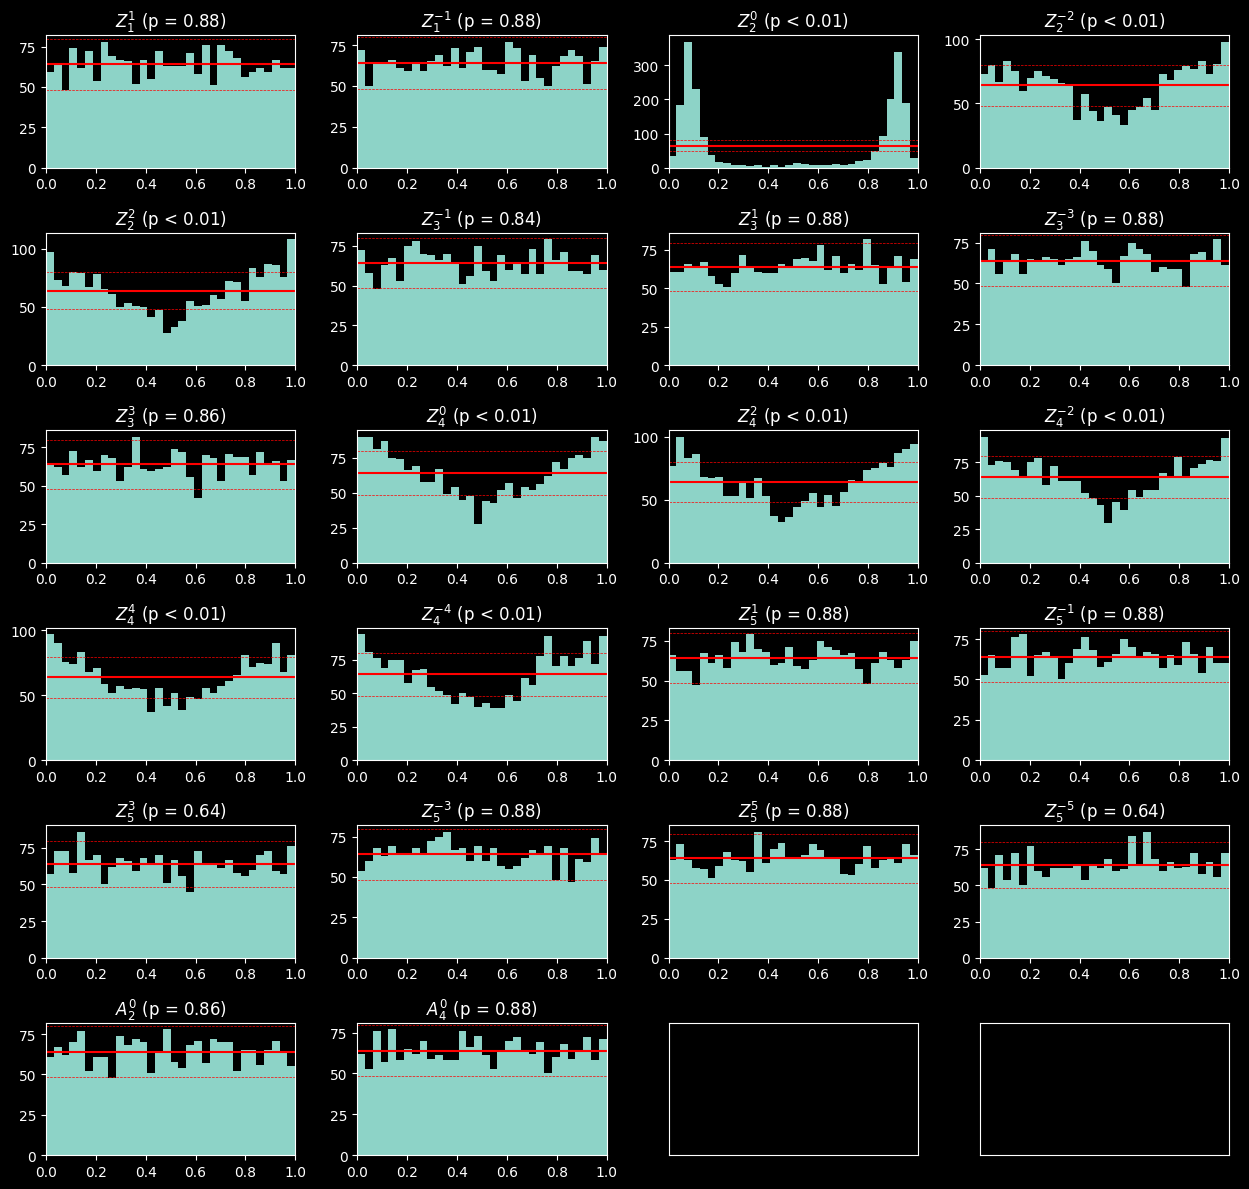

In [19]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7
num_coefs = ranks.shape[-1]

num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)
labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        out = ax.hist(ranks[:, i].numpy(force=True), range=(0, 1), bins=num_bins)
        ax.axhline(uniform_mean, ls="-", color="r")
        ax.axhline(uniform_mean - 2*uniform_std, ls="--", lw=0.5, color="r")
        ax.axhline(uniform_mean + 2*uniform_std, ls="--", lw=0.5, color="r")
        ax.set_ylim(bottom=0)
        ax.set_xlim(0, 1)

        p_lbl = f"p = {pvalues[i]:.2f}" if pvalues[i] > 0.01 else "p < 0.01"
        ax.set_title(f"{solver.coefficients.nonpinned_labels[i]} ({p_lbl})")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

Solid horizontal lines show the mean expected from a uniform distribution, dashed horizontal lines are at $\pm 2\sigma$. Subplot titles give the significance at which each dataset rejects the uniform null hypothesis.

Different parameters show different degrees of calibration. The odd-$n$ phase terms are all statistically indistinguishable from uniform distributions, while the even-$n$ phase terms all show a U-shape that often indicates overconfident predictions. The amplitude terms appear uniformly distributed, but as discussed above, the model isn't really sensitive enough to these for it to mean anything one way or another.

#### Diagnosing the problem

The $Z_2^0$ term is particularly striking. In particular, although it has a U-shape that typically suggests a narrow predicted distribution, the peaks aren't quite at 0 and 1, as would be expected from a strictly overconfident prediction (where the truth would be more likely to be first or last in the ordering). Dual peaks at intermediate values could be related to miscalibration of the means, rather than of the standard deviations.

Compare the true coefficients (post z-jittering) to the mean predictions (choosing the component nearest the truth).

In [20]:
batch_size = 64

defocus_coefs = solver.simulator.z_offset_to_coefficients(z)  # [Z, N_phase]
phase_labels = phase_coefs.unsqueeze(1) + defocus_coefs.unsqueeze(0)  # [B, Z, N_phase]
amp_labels = amp_coefs.unsqueeze(1).expand(-1, num_z, -1)  # [B, Z, N_amp]
truth = solver.coefficients.join(phase_labels.flatten(0, 1), amp_labels.flatten(0, 1))
truth = truth[:, ~solver.coefficients.is_pinned].reshape(batch_size, num_z, -1)  # [B, Z, C_kept]

pred_means = dist.mean.reshape(batch_size, num_z, solver.num_components, -1)  # [B, Z, K, C_kept]
nearest_component = (pred_means - truth.unsqueeze(2)).square().sum(-1).argmin(-1)  # [B, Z], index of the correct twin
nearest_means = pred_means[torch.arange(batch_size).unsqueeze(1), torch.arange(num_z).unsqueeze(0), nearest_component]  # [B, Z, C_kept]

pred_stdevs = dist.stddev.reshape(batch_size, num_z, solver.num_components, -1)  # [B, Z, K, C_kept]
nearest_stdevs = pred_stdevs[torch.arange(batch_size).unsqueeze(1), torch.arange(num_z).unsqueeze(0), nearest_component]  # [B, Z, C_kept]

zscores = (truth - nearest_means) / nearest_stdevs  # [B, Z, C_kept]

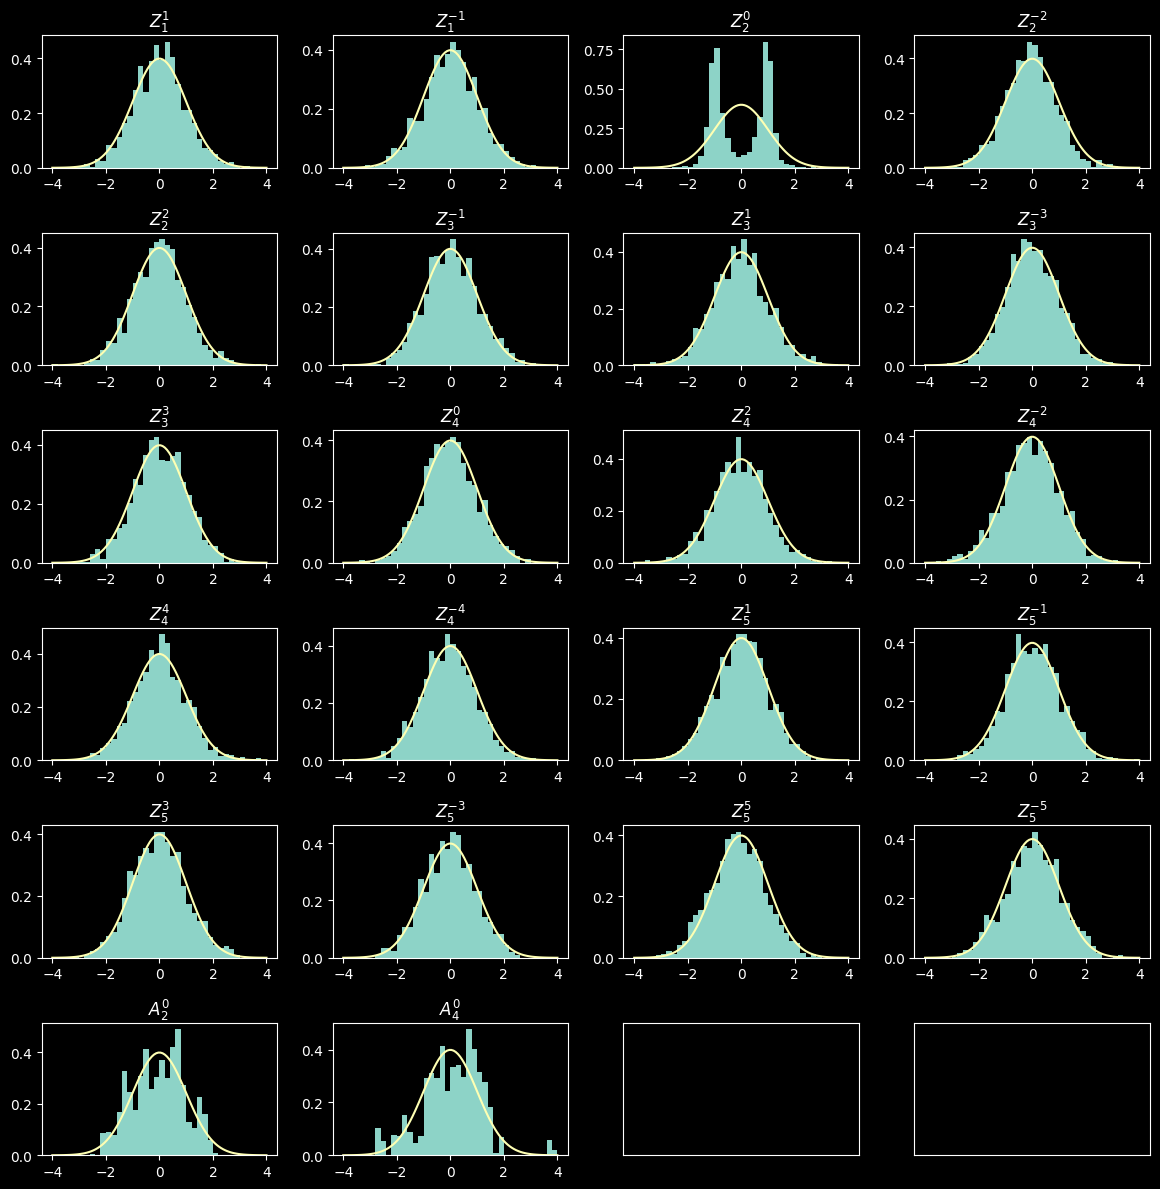

In [21]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.65

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

xmax = 4
x = np.linspace(-xmax, xmax, 100)
standard_normal = (1.0/math.sqrt(2*math.pi)) * np.exp(-0.5*x**2)

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        _ = ax.hist(zscores[..., i].numpy(force=True).ravel(), range=(-xmax, xmax), bins=40, density=True)
        ax.plot(x, standard_normal)
        ax.set_title(f"{labels[i]}")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

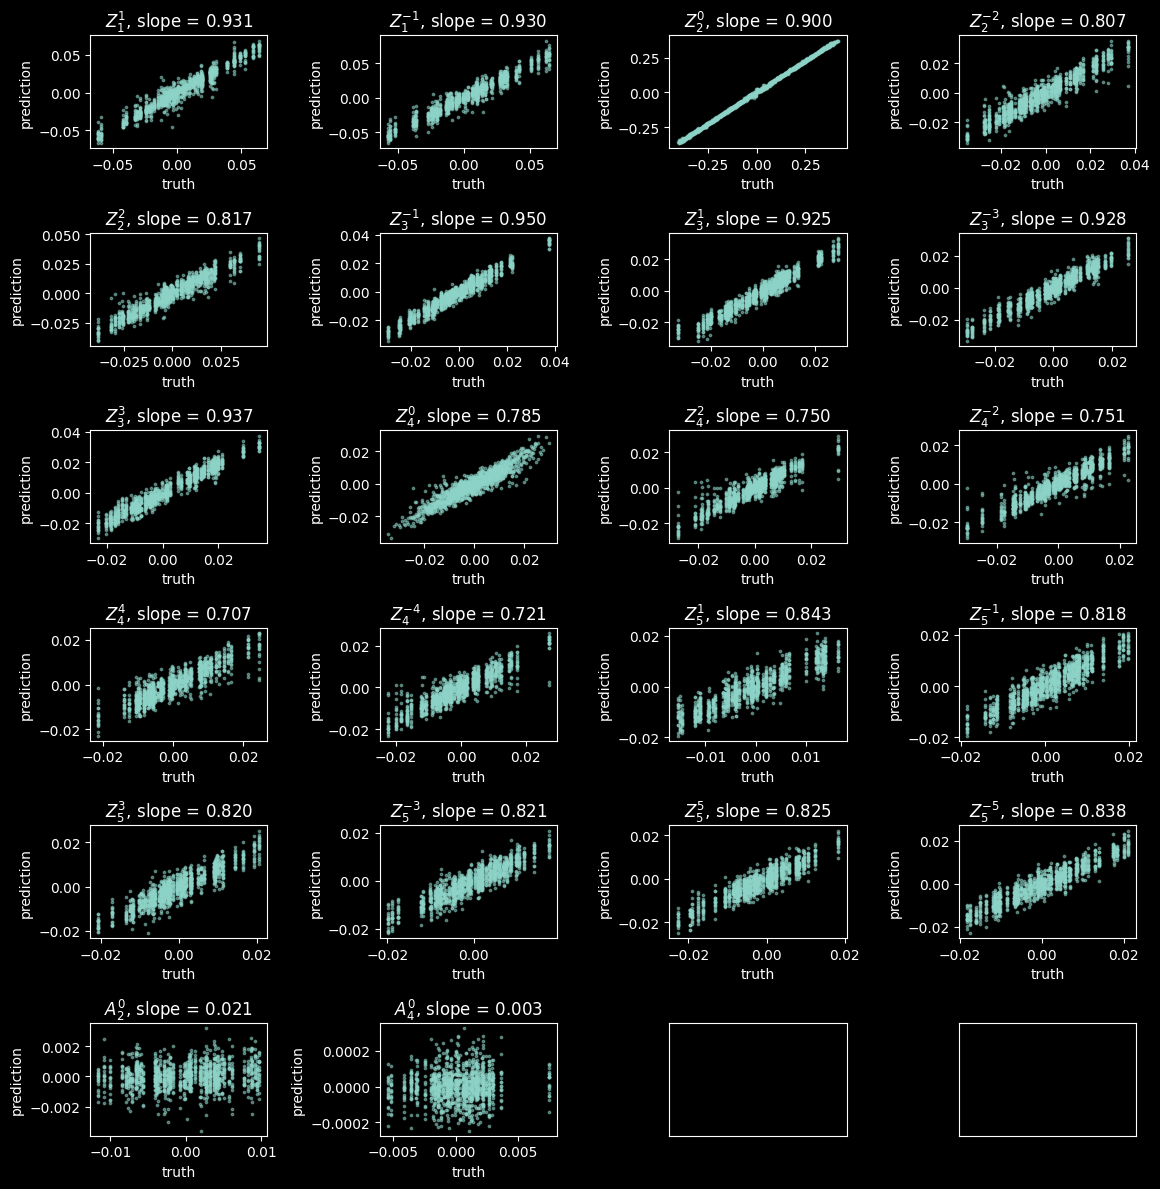

In [22]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.65

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        true_coef = truth[..., i].numpy(force=True).ravel()
        pred_coef = nearest_means[..., i].numpy(force=True).ravel()
        ax.scatter(true_coef, pred_coef, s=3, alpha=0.5)
        slope = np.polyfit(true_coef, pred_coef, deg=1)[0]
        ax.set_title(f"{labels[i]}, slope = {slope:.3f}")
        ax.set_ylabel("prediction")
        ax.set_xlabel("truth")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

$Z_2^0$ is again the stand-out. In the z-score domain, every coefficient is well-modeled by a standard normal distribution, except for $Z_2^0$ which shows two peaks at $\pm$1. In the slope domain, every coefficient shows a slope of <1, but none is clearer than $Z_2^0$'s very tight spread with a slope of exactly 0.900. This is all consistent with the uncertainties being correctly predicted, but the means being off by some constant factor.

The slope of 0.900 fits the min component allocation of 0.05. Given a true target x, the dual components for the even-n terms are at $\pm$x, so the mean gets diluted to 0.95x - 0.05x = 0.90x. If this is indeed the culprit, dropping the min component allocation should resolve it. We'll just have to hope the mixing entropy loss can stave off component collapse on its own.

#### Fixing the calibration

The next few cells are the same as above, just with a different MixtureConfig.

In [23]:
mixture_cfg = get_default_mixture_config()

In [24]:
_ = pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_MixedDensity(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    mixture_cfg=mixture_cfg,
    noise_cfg=noise_cfg,
    encoder_spec=encoder_spec,
)
solver = solver.to(device)

Seed set to 123


In [25]:
checkpoint_path = Path("./pretrained_models/example_3a_ii/checkpoints/final.ckpt")
if use_pretrained and checkpoint_path.is_file():
    solver = safe_load_from_checkpoint(checkpoint_path, solver).eval()
else:
    trainer = pl.Trainer(
        max_epochs=600,  # much longer than usual, to tighten the bounds
        accelerator=device,
        log_every_n_steps=100,
        callbacks=[NoValidationBar()],
        gradient_clip_val=1.0,
    )
    trainer.fit(solver)
    solver = solver.eval()

In [26]:
_ = pl.seed_everything(rng_seed+3, workers=True)
solver = solver.to(device)

Seed set to 126


In [27]:
batch_size = 64
z_max = 1.5
num_z = 19

z = torch.linspace(-z_max, z_max, num_z, device=solver.device)
phase_coefs, amp_coefs = solver.simulator.sample_coefficients(batch_size)

In [28]:
with torch.inference_mode():
    z_exp = z.unsqueeze(0).expand((batch_size, num_z)).reshape(batch_size*num_z)
    defocus_exp = solver.propagator.defocus_from_objective_z(z_exp)
    phase_coefs_exp = phase_coefs.unsqueeze(1).expand((batch_size, num_z, -1)).reshape(batch_size*num_z, -1)
    amp_coefs_exp = amp_coefs.unsqueeze(1).expand((batch_size, num_z, -1)).reshape(batch_size*num_z, -1)

    images = solver.simulator.simulate_stacks(defocus_exp, phase_coefs_exp, amp_coefs_exp)
    images = solver.simulator.apply_noise(images)
    images = solver.simulator.normalize_stack(images)
    mixture_family = solver.predict_distribution(images)

mixture = mixture_family.mixture_distribution
dist = mixture_family.component_distribution

covariances = dist.covariance_matrix
sigmas = covariances.diagonal(dim1=-2, dim2=-1).sqrt()
sigmas = sigmas.reshape(batch_size, num_z, solver.num_components, -1)  # [B, Z, num_components, num_coefficients]

images = images.squeeze(1).unflatten(0, (batch_size, num_z))  # [B*Z, 1, H, W] -> [B, Z, H, W]

In [29]:
fisher_matrix_samples = []
coefs = solver.coefficients.gather_nonpinned(solver.coefficients.join(phase_coefs, amp_coefs))  # [B, C_kept]
for coefs_i in coefs:  # TODO - figure out a way to vectorize this later
    _, fisher_matrix = calculate_fisher_matrix(coefs_i, z, solver.simulator)
    fisher_matrix_samples.append(fisher_matrix.numpy(force=True))

num_coefs = solver.coefficients.num_nonpinned_coefs
fisher_matrix_samples = np.concatenate(fisher_matrix_samples)
fisher_matrix_samples = fisher_matrix_samples.reshape(batch_size, z.shape[0], num_coefs, num_coefs)  # [B, Z, C_kept, C_kept]
fisher_matrix = fisher_matrix_samples.mean(0)  # [Z, C_kept, C_kept]

In [30]:
prior_sigmas = solver.coefficients.target_scales[~solver.coefficients.is_pinned].numpy(force=True)
prior_covariance = np.diag(prior_sigmas)**2
van_trees = calculate_van_trees_bounds(fisher_matrix, prior_covariance)

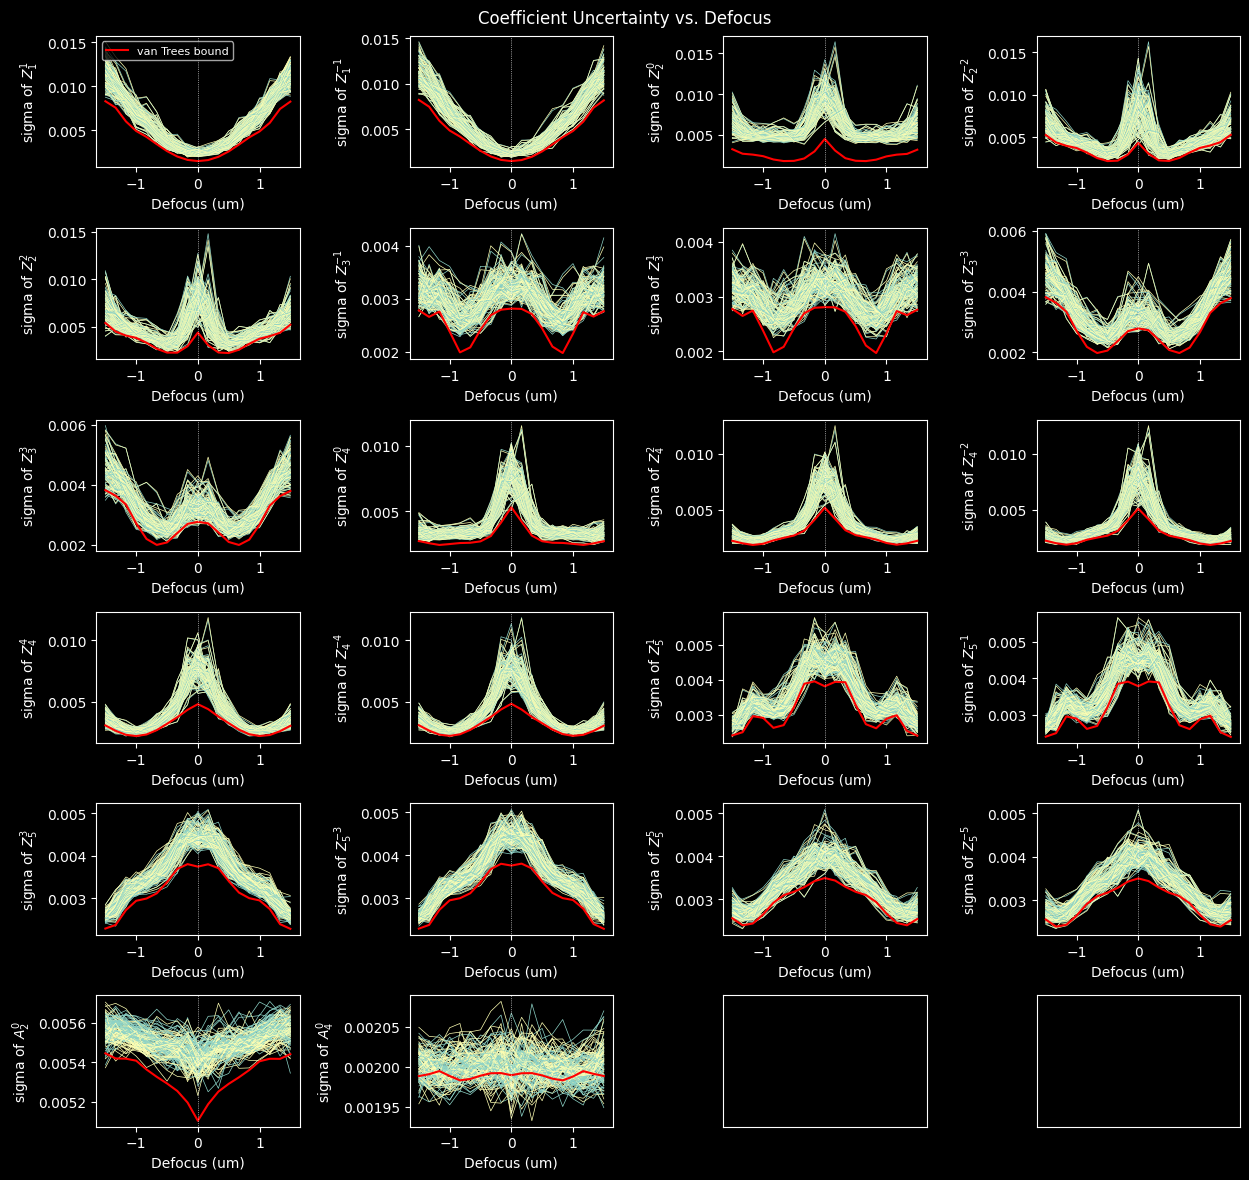

In [31]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        for bidx, cidx in itertools.product(range(batch_size), range(solver.num_components)):
            ax.plot(z.numpy(force=True), sigmas[bidx, :, cidx, i].numpy(force=True), lw=0.5, color=f"C{cidx}")
        ax.plot(z.numpy(force=True), van_trees[:, i], color="r", label="van Trees bound")
        ax.set_ylabel(f"sigma of {labels[i]}")
        ax.set_xlabel("Defocus (um)")
        ax.axvline(0, ls=":", lw=0.5)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
axarr[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Coefficient Uncertainty vs. Defocus")
fig.tight_layout()

Well would you look at that, $\sigma(Z_2^0)$ has been suppressed, and is looking a lot more like the van Trees bound now. That's encouraging, now rerun the SBC check.

In [32]:
batch_size = 2048
num_samples = 512
num_bins = 32

In [33]:
_ = pl.seed_everything(rng_seed+4, workers=True)
coef_blocks, pred_coef_blocks = generate_and_predict(solver, batch_size, num_samples, chunk_size=8)
ranks = []
for cb, pcb in zip(coef_blocks, pred_coef_blocks):
    r = calculate_rank_statistics(cb, pcb)
    ranks.append(r)
ranks = torch.cat(ranks, dim=-1)
ranks = ranks[:, ~solver.coefficients.is_pinned.cpu()]

uniform_mean, uniform_std = get_expected_rank_statistics(batch_size, num_bins)
pvalues = test_rank_uniformity(ranks, num_bins)

Seed set to 127


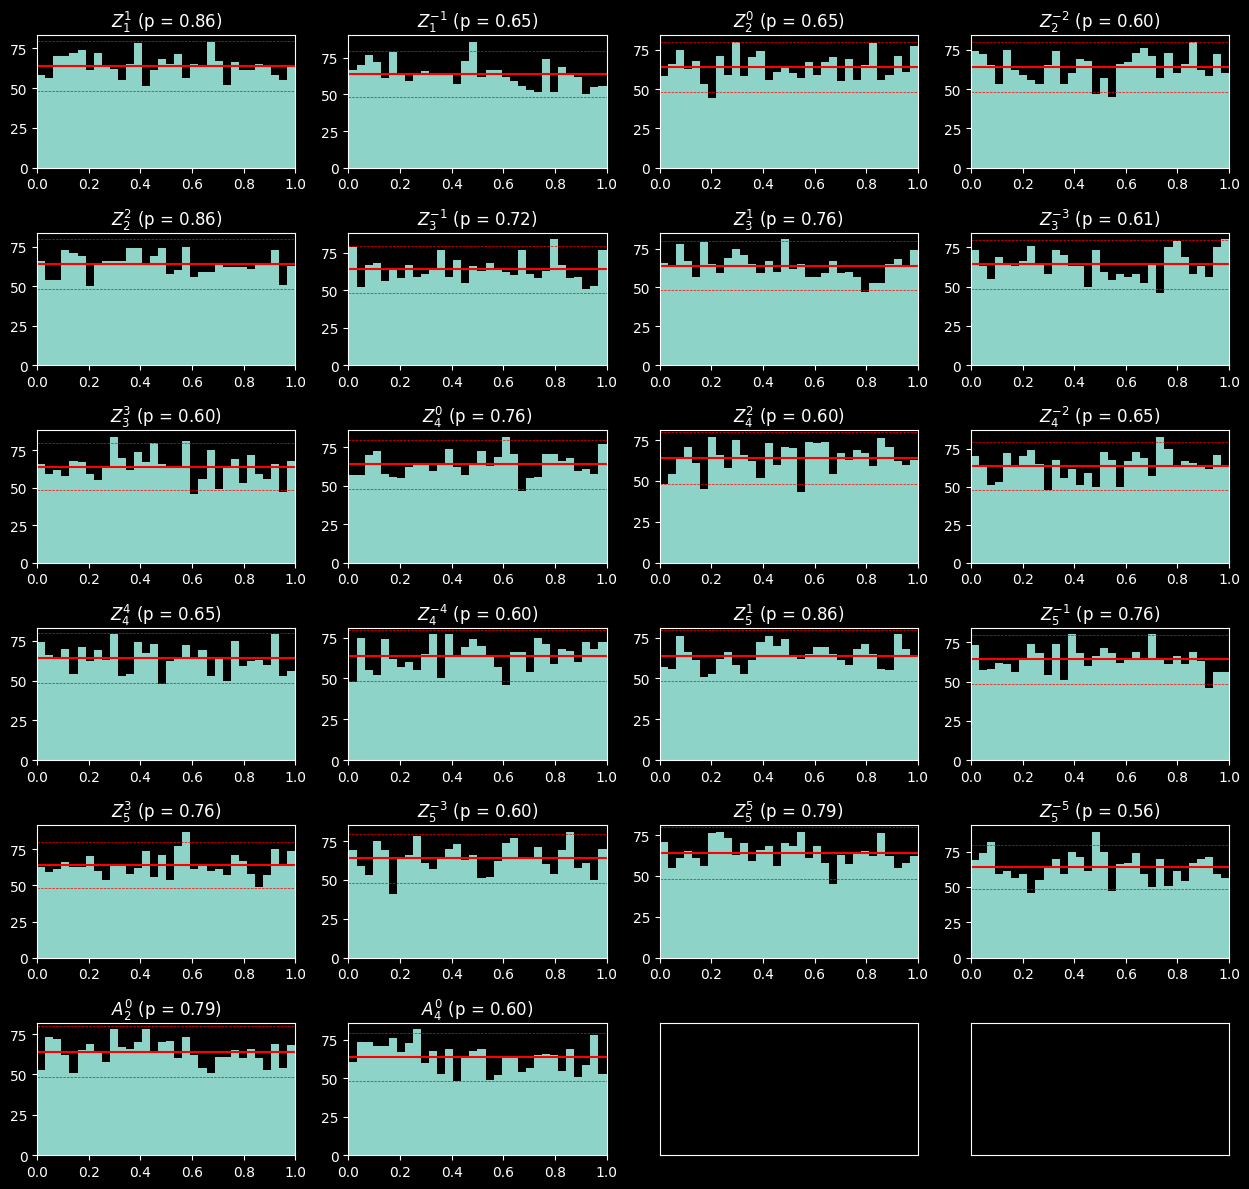

In [34]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7
num_coefs = ranks.shape[-1]

num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)
labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        out = ax.hist(ranks[:, i].numpy(force=True), range=(0, 1), bins=num_bins)
        ax.axhline(uniform_mean, ls="-", color="r")
        ax.axhline(uniform_mean - 2*uniform_std, ls="--", lw=0.5, color="r")
        ax.axhline(uniform_mean + 2*uniform_std, ls="--", lw=0.5, color="r")
        ax.set_ylim(bottom=0)
        ax.set_xlim(0, 1)

        p_lbl = f"p = {pvalues[i]:.2f}" if pvalues[i] > 0.01 else "p < 0.01"
        ax.set_title(f"{solver.coefficients.nonpinned_labels[i]} ({p_lbl})")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

All of the coefficients now show statistically uniform rank statistic distributions at the p=0.05 significance level. That's actually kind of surprising, since with 22 coefficients plotted, it wouldn't have been unusual for one to show non-uniformity at p<0.05 significance even if they were all truly uniform.